# Advanced Algorithms for Data Science: Comparative Research Notebook

## Final Project (Graduate Level)

### Author
Kalkidan Debassu

### Abstract
This notebook presents a research-oriented comparative study of five algorithmic paradigms across four heterogeneous data settings: tabular regression (California Housing), high-dimensional image classification (MNIST), medical diagnosis classification (Breast Cancer), and sequential decision making (FrozenLake). We implement and analyze **Lambda-connectedness**, **K-means**, **SVM**, **Neural Networks**, and **Q-learning** from a practical algorithmic perspective.

The goal is not only to report metrics, but to explain **why** each method behaves as observed, how data geometry affects optimization and generalization, and why no single method dominates all tasks.

## Research Objectives and Questions

### Objectives
1. Build end-to-end pipelines from preprocessing to interpretation.
2. Compare clustering, classification, regression, and reinforcement learning methods.
3. Connect empirical outcomes to mathematical properties and data structure.
4. Evaluate tradeoffs among accuracy, complexity, scalability, interpretability, and robustness.

### Core Research Questions
1. Why do nonlinear models (SVM-RBF, neural networks) often outperform linear boundaries on MNIST?
2. Why can K-means succeed on some datasets and fail on non-spherical or imbalanced structures?
3. Why does SVM perform strongly in Breast Cancer diagnosis despite modest data size?
4. Why does RL fail early in FrozenLake training and then improve later?
5. Why does preprocessing (scaling, dimensionality reduction) significantly affect model quality?
6. Why is algorithm suitability fundamentally dataset-dependent?

In [1]:
# ===============================
# 1) Imports and Reproducibility
# ===============================
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing, load_breast_cancer, fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

from sklearn.cluster import KMeans
from sklearn.svm import SVC, SVR
from sklearn.neural_network import MLPClassifier, MLPRegressor

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    mean_squared_error,
    r2_score,
    silhouette_score,
    adjusted_rand_score,
)
from sklearn.metrics.pairwise import euclidean_distances

warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print('Imports ready.')

Imports ready.


## Mathematical Intuition and Time Complexity

### 1) K-means Clustering
Objective:
$$\min_{\{C_k\},\{\mu_k\}} \sum_{k=1}^{K}\sum_{x_i \in C_k} \|x_i - \mu_k\|_2^2$$
Intuition: alternates between assignment and centroid update, converging to a local optimum.

Typical complexity per iteration: $O(nkd)$ where $n$ is samples, $k$ clusters, $d$ features. Total $O(nkdi)$ for $i$ iterations.

### 2) Support Vector Machine (SVM)
Hard-margin intuition: maximize margin while separating classes:
$$\min_{w,b} \frac{1}{2}\|w\|^2 \quad \text{s.t. } y_i(w^T x_i + b) \ge 1$$
Kernel trick maps nonlinearly separable data into higher-dimensional feature space.

Training complexity depends on solver and kernel; for kernel SVM often between $O(n^2d)$ and $O(n^3)$ with memory around $O(n^2)$.

### 3) Neural Networks (MLP)
Parameterized nonlinear composition with gradient descent/backpropagation.

Per epoch complexity is roughly proportional to number of parameters and samples:
$$O(n \cdot p)$$
where $p$ is total trainable weights.

### 4) Lambda-connectedness
Build similarity graph $G=(V,E)$ with edge if similarity $s_{ij} \ge \lambda$.
Connected components in thresholded graph define clusters.

Pairwise distance graph construction is $O(n^2d)$; graph traversal (DFS/BFS) is $O(n+e)$.

### 5) Q-learning (FrozenLake)
Bellman update:
$$Q(s,a) \leftarrow Q(s,a) + \alpha\left[r + \gamma\max_{a'}Q(s',a') - Q(s,a)\right]$$

Tabular update per step is $O(1)$; total complexity scales with episodes and steps, i.e., $O(E \cdot T)$.

In [2]:
# =========================================
# 2) Utilities: timing, reporting, lambda graph
# =========================================
runtime_log = []
results = []


def log_runtime(section, start_time):
    runtime_log.append({'Section': section, 'Runtime_sec': time.time() - start_time})


def add_result(dataset, algorithm, metric, value):
    results.append({
        'Dataset': dataset,
        'Algorithm': algorithm,
        'Metric': metric,
        'Value': float(value) if np.isscalar(value) else value,
    })


def clustering_report(X, labels, y_true=None):
    out = {}
    out['n_clusters'] = int(len(np.unique(labels)))
    out['silhouette'] = float(silhouette_score(X, labels)) if len(np.unique(labels)) > 1 else np.nan
    out['ari'] = float(adjusted_rand_score(y_true, labels)) if y_true is not None else np.nan
    return out


def lambda_connected_components(X, lambda_threshold=0.75, sample_limit=2500):
    # Optional downsampling for O(n^2) distance construction.
    if X.shape[0] > sample_limit:
        idx = np.random.choice(X.shape[0], sample_limit, replace=False)
        X_work = X[idx]
    else:
        idx = np.arange(X.shape[0])
        X_work = X

    D = euclidean_distances(X_work, X_work)
    sigma = np.median(D[D > 0]) if np.any(D > 0) else 1.0
    S = np.exp(-(D ** 2) / (2 * sigma ** 2 + 1e-12))
    A = S >= lambda_threshold

    n = A.shape[0]
    labels = -np.ones(n, dtype=int)
    comp_id = 0

    for i in range(n):
        if labels[i] != -1:
            continue
        stack = [i]
        labels[i] = comp_id
        while stack:
            u = stack.pop()
            neighbors = np.where(A[u])[0]
            for v in neighbors:
                if labels[v] == -1:
                    labels[v] = comp_id
                    stack.append(v)
        comp_id += 1

    return idx, labels

print('Utilities ready.')

Utilities ready.


## Datasets, Structure, and Preprocessing Rationale

### Datasets
1. **California Housing**: tabular regression; socioeconomic and geospatial proxies for median house value.
2. **Breast Cancer**: medical diagnostic binary classification (malignant vs benign) with engineered cellular features.
3. **MNIST**: high-dimensional grayscale digit images (784 features).
4. **FrozenLake**: stochastic reinforcement learning environment with delayed sparse rewards.

### Why Preprocessing Matters
- **Feature scaling**: distance- and margin-based models (K-means, SVM, MLP) are sensitive to magnitude differences.
- **Dimensionality reduction**: improves visualization and can reduce noise in high-dimensional spaces.
- **Subsampling**: required for computational feasibility on $O(n^2)$ graph methods.
- **Train/test separation**: prevents leakage and yields honest generalization estimates.

### Dataset Challenges
- Housing: heteroscedastic targets and latent socioeconomic confounders.
- Breast Cancer: class imbalance sensitivity in medical risk context.
- MNIST: high dimension and overlapping class manifolds (e.g., 4 vs 9).
- FrozenLake: sparse delayed reward and stochastic transitions.

In [3]:
# ===============================
# 3) Load datasets and summarize
# ===============================
start = time.time()

housing = fetch_california_housing()
X_housing, y_housing = housing.data, housing.target

bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target

# Subsample MNIST for practical runtime in class project settings.
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_mnist = mnist.data.astype(np.float32) / 255.0
y_mnist = mnist.target.astype(int)

summary_df = pd.DataFrame([
    {'Dataset': 'California Housing', 'Samples': X_housing.shape[0], 'Features': X_housing.shape[1], 'Task': 'Regression'},
    {'Dataset': 'Breast Cancer', 'Samples': X_bc.shape[0], 'Features': X_bc.shape[1], 'Task': 'Binary Classification'},
    {'Dataset': 'MNIST', 'Samples': X_mnist.shape[0], 'Features': X_mnist.shape[1], 'Task': 'Multiclass Classification'},
    {'Dataset': 'FrozenLake', 'Samples': 16, 'Features': 1, 'Task': 'RL (MDP states)'}
])

log_runtime('Dataset Loading', start)
summary_df

,Dataset,Samples,Features,Task
0,California Housing,20640,8,Regression
1,Breast Cancer,569,30,Binary Classification
2,MNIST,70000,784,Multiclass Classification
3,FrozenLake,16,1,RL (MDP states)


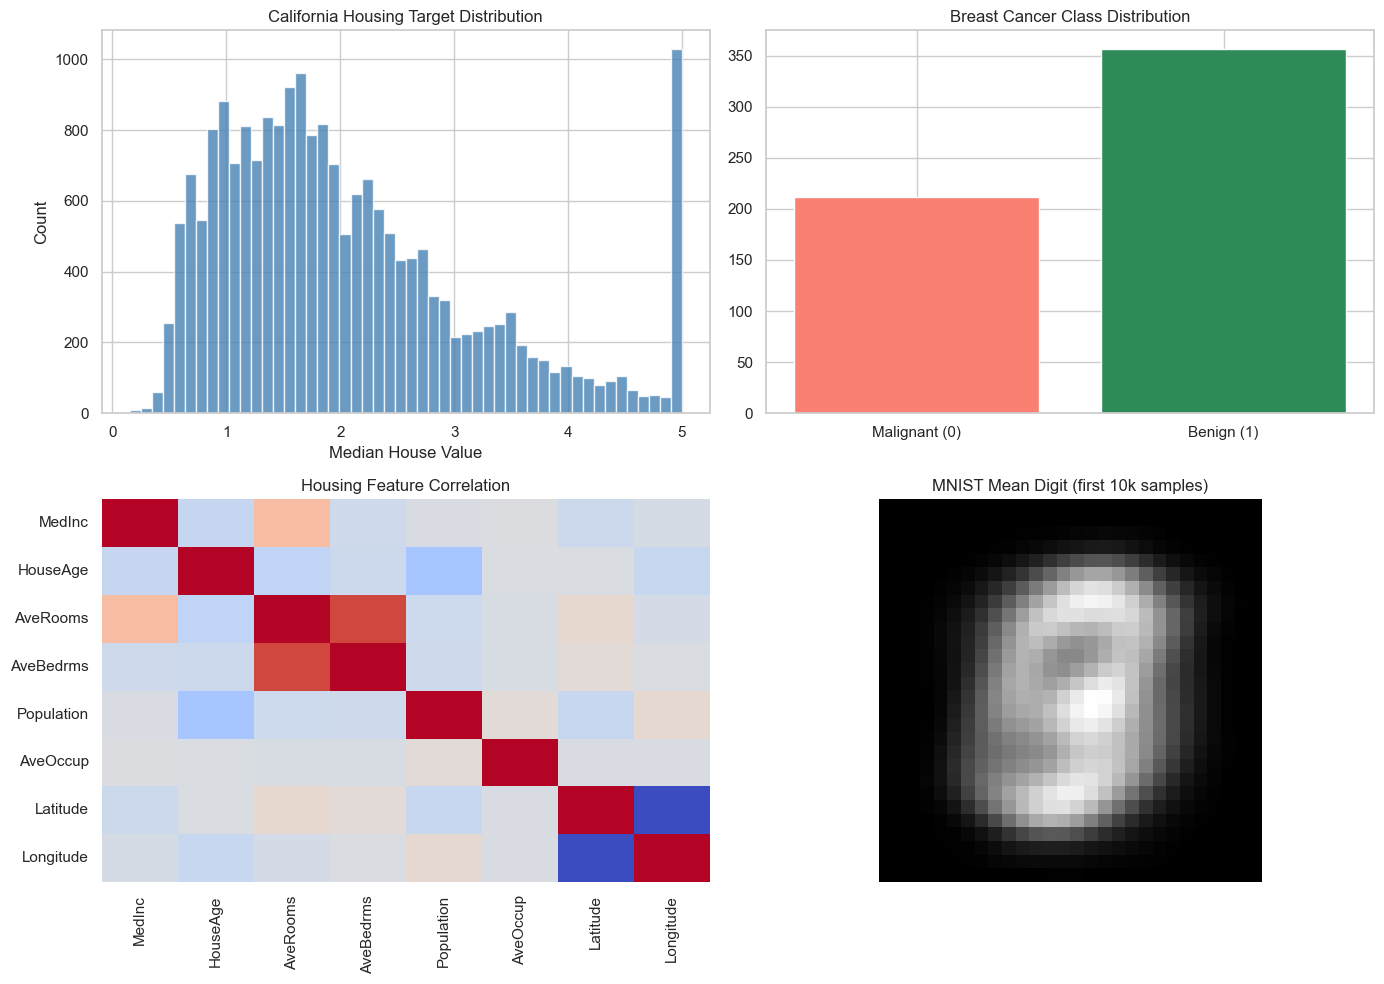

In [4]:
# =====================================
# 4) EDA: distributions and correlations
# =====================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Housing target distribution.
axes[0, 0].hist(y_housing, bins=50, color='steelblue', alpha=0.8)
axes[0, 0].set_title('California Housing Target Distribution')
axes[0, 0].set_xlabel('Median House Value')
axes[0, 0].set_ylabel('Count')

# Breast cancer class balance.
bc_counts = pd.Series(y_bc).value_counts().sort_index()
axes[0, 1].bar(['Malignant (0)', 'Benign (1)'], bc_counts.values, color=['salmon', 'seagreen'])
axes[0, 1].set_title('Breast Cancer Class Distribution')

# Housing correlation heatmap on a subset of features.
housing_df = pd.DataFrame(X_housing, columns=housing.feature_names)
corr = housing_df.corr()
sns.heatmap(corr, cmap='coolwarm', ax=axes[1, 0], cbar=False)
axes[1, 0].set_title('Housing Feature Correlation')

# MNIST average image.
mean_digit = X_mnist[:10000].mean(axis=0).reshape(28, 28)
axes[1, 1].imshow(mean_digit, cmap='gray')
axes[1, 1].set_title('MNIST Mean Digit (first 10k samples)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## California Housing: K-means, Lambda-connectedness, and Neural/SVM Regression

This section focuses on market segmentation and regression accuracy.

Interpretive focus:
1. Do latent housing segments appear after scaling and PCA?
2. Are graph-connected components indicating density-based neighborhood structures?
3. How do SVM and MLP compare in regression bias-variance behavior?

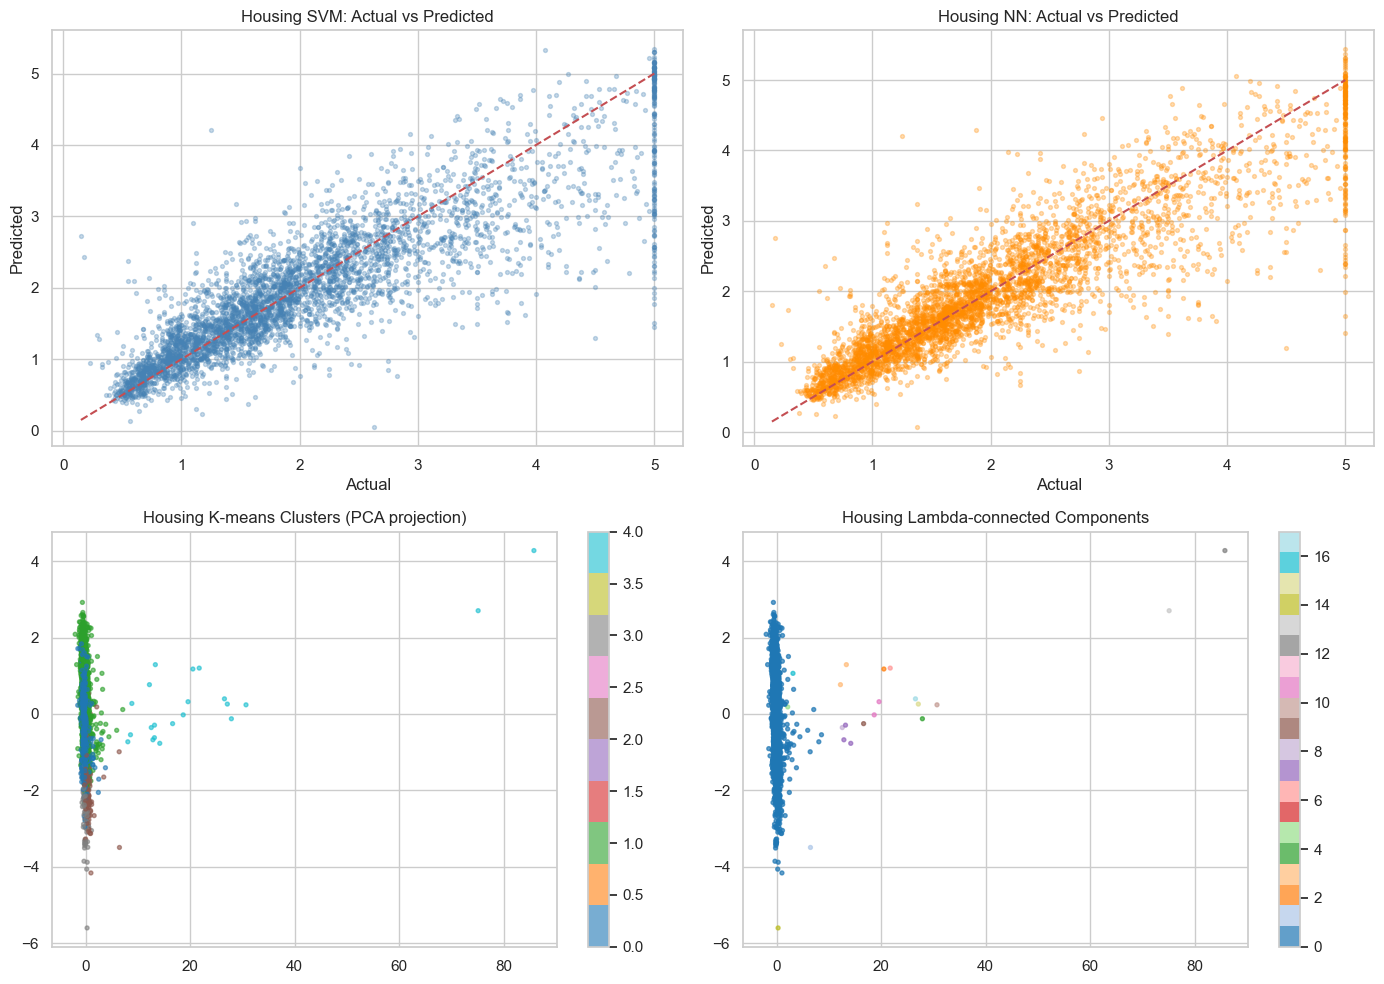

In [5]:
start = time.time()

# Split data.
Xh_train, Xh_test, yh_train, yh_test = train_test_split(X_housing, y_housing, test_size=0.2, random_state=42)

# Scale features.
scaler_h = StandardScaler()
Xh_train_s = scaler_h.fit_transform(Xh_train)
Xh_test_s = scaler_h.transform(Xh_test)
Xh_all_s = scaler_h.fit_transform(X_housing)

# SVM regressor.
svm_h = SVR(C=15, epsilon=0.1, kernel='rbf')
svm_h.fit(Xh_train_s, yh_train)
yh_pred_svm = svm_h.predict(Xh_test_s)
add_result('Housing', 'SVM', 'RMSE', np.sqrt(mean_squared_error(yh_test, yh_pred_svm)))
add_result('Housing', 'SVM', 'R2', r2_score(yh_test, yh_pred_svm))

# Neural network regressor.
nn_h = MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=120, random_state=42)
nn_h.fit(Xh_train_s, yh_train)
yh_pred_nn = nn_h.predict(Xh_test_s)
add_result('Housing', 'Neural Network', 'RMSE', np.sqrt(mean_squared_error(yh_test, yh_pred_nn)))
add_result('Housing', 'Neural Network', 'R2', r2_score(yh_test, yh_pred_nn))

# K-means clustering with target bin proxy for ARI.
kmeans_h = KMeans(n_clusters=6, random_state=42, n_init=15)
kh_labels = kmeans_h.fit_predict(Xh_all_s)
y_h_bins = pd.qcut(y_housing, q=6, labels=False, duplicates='drop')
kh_rep = clustering_report(Xh_all_s, kh_labels, y_h_bins)
add_result('Housing', 'K-means', 'Silhouette', kh_rep['silhouette'])
add_result('Housing', 'K-means', 'ARI_vs_binned_target', kh_rep['ari'])

# Lambda-connectedness on PCA projection.
Xh_pca = PCA(n_components=6, random_state=42).fit_transform(Xh_all_s[:3000])
idx_h, lmb_h_labels = lambda_connected_components(Xh_pca, lambda_threshold=0.72, sample_limit=2500)
lmb_h_rep = clustering_report(Xh_pca[idx_h], lmb_h_labels)
add_result('Housing', 'Lambda-connectedness', 'NumClusters', lmb_h_rep['n_clusters'])
add_result('Housing', 'Lambda-connectedness', 'Silhouette', lmb_h_rep['silhouette'])

# Visual summary.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(yh_test, yh_pred_svm, alpha=0.3, s=8, color='steelblue')
axes[0, 0].plot([yh_test.min(), yh_test.max()], [yh_test.min(), yh_test.max()], 'r--')
axes[0, 0].set_title('Housing SVM: Actual vs Predicted')
axes[0, 0].set_xlabel('Actual')
axes[0, 0].set_ylabel('Predicted')

axes[0, 1].scatter(yh_test, yh_pred_nn, alpha=0.3, s=8, color='darkorange')
axes[0, 1].plot([yh_test.min(), yh_test.max()], [yh_test.min(), yh_test.max()], 'r--')
axes[0, 1].set_title('Housing NN: Actual vs Predicted')
axes[0, 1].set_xlabel('Actual')
axes[0, 1].set_ylabel('Predicted')

Xh_pca2 = PCA(n_components=2, random_state=42).fit_transform(Xh_all_s[:3000])
sc1 = axes[1, 0].scatter(Xh_pca2[:, 0], Xh_pca2[:, 1], c=kh_labels[:3000], cmap='tab10', s=8, alpha=0.6)
axes[1, 0].set_title('Housing K-means Clusters (PCA projection)')
plt.colorbar(sc1, ax=axes[1, 0])

sc2 = axes[1, 1].scatter(Xh_pca[idx_h, 0], Xh_pca[idx_h, 1], c=lmb_h_labels, cmap='tab20', s=8, alpha=0.7)
axes[1, 1].set_title('Housing Lambda-connected Components')
plt.colorbar(sc2, ax=axes[1, 1])

plt.tight_layout()
plt.show()

log_runtime('Housing Experiments', start)

### Housing Interpretation (Why Results Occur)

1. **Segment formation**: K-means captures centroid-based socioeconomic segments, often driven by median income and location-proxy features.
2. **Why preprocessing helped**: Without scaling, large-range features dominate Euclidean distances, producing distorted clusters.
3. **Lambda-connectedness insight**: It discovers connectivity islands rather than centroid partitions, revealing local density relationships.
4. **Regression behavior**: SVM-RBF and MLP both model nonlinearity; differences emerge from optimization dynamics and regularization.
5. **Socioeconomic meaning**: clusters may correspond to affordability tiers, suburban vs urban dynamics, and regional value regimes.

## Breast Cancer: SVM, K-means, and Neural Network Analysis

Medical context requires focus on false negatives (missing malignant cases) and model reliability.

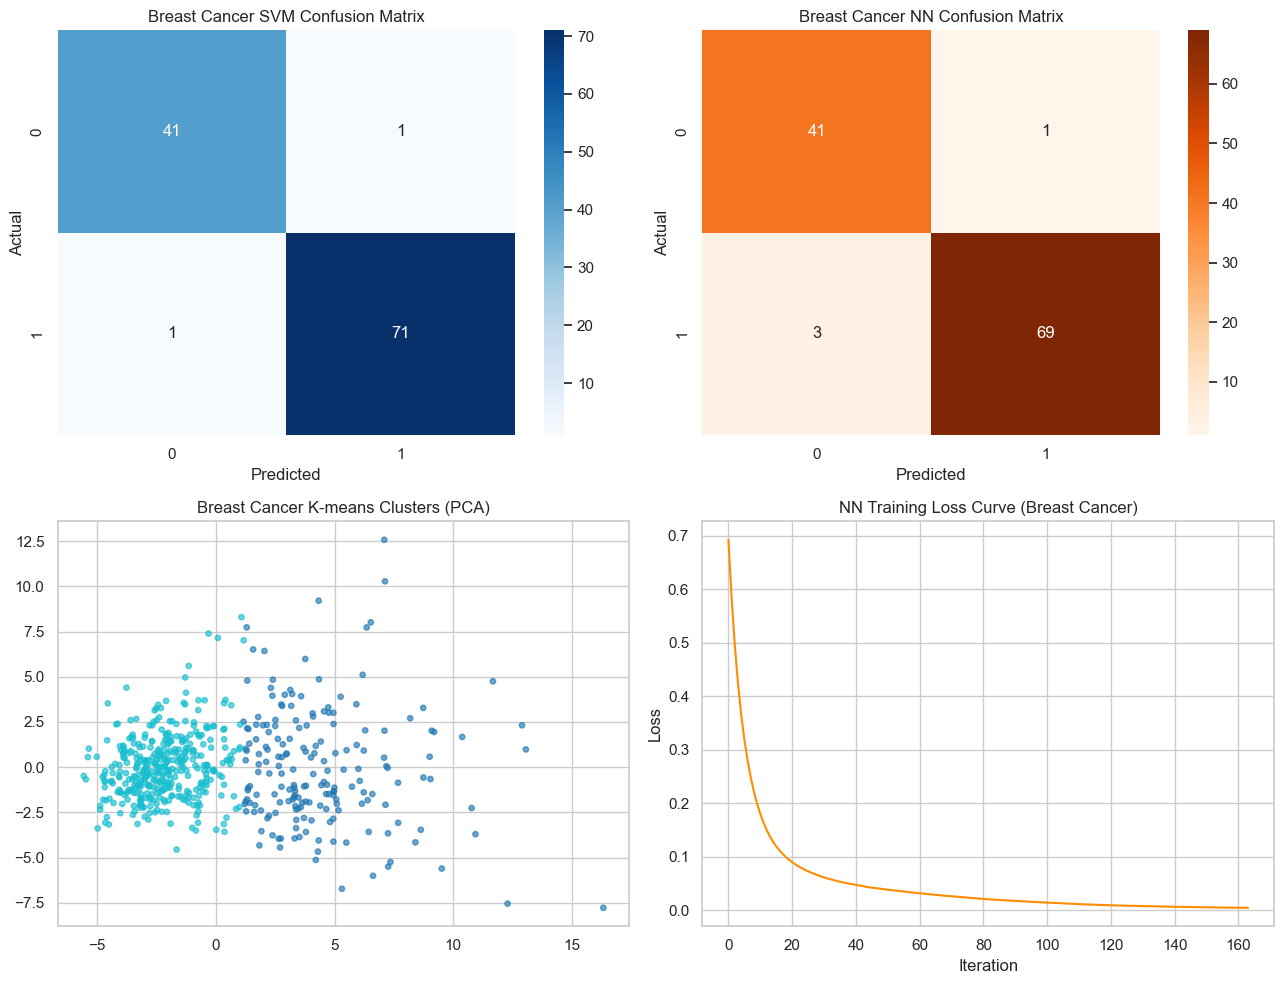

In [6]:
start = time.time()

Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_bc, y_bc, test_size=0.2, stratify=y_bc, random_state=42)
scaler_b = StandardScaler()
Xb_train_s = scaler_b.fit_transform(Xb_train)
Xb_test_s = scaler_b.transform(Xb_test)
Xb_all_s = scaler_b.fit_transform(X_bc)

# Compare linear vs RBF SVM to analyze separability.
svm_b_lin = SVC(kernel='linear', C=1.0, random_state=42)
svm_b_rbf = SVC(kernel='rbf', C=5.0, gamma='scale', random_state=42)
svm_b_lin.fit(Xb_train_s, yb_train)
svm_b_rbf.fit(Xb_train_s, yb_train)

yb_pred_lin = svm_b_lin.predict(Xb_test_s)
yb_pred_rbf = svm_b_rbf.predict(Xb_test_s)

# Select the better performer for downstream reporting.
acc_lin = accuracy_score(yb_test, yb_pred_lin)
acc_rbf = accuracy_score(yb_test, yb_pred_rbf)
svm_b = svm_b_rbf if acc_rbf >= acc_lin else svm_b_lin
yb_pred_svm = yb_pred_rbf if acc_rbf >= acc_lin else yb_pred_lin

add_result('Breast Cancer', 'SVM', 'Accuracy', accuracy_score(yb_test, yb_pred_svm))
add_result('Breast Cancer', 'SVM', 'Precision', precision_score(yb_test, yb_pred_svm))
add_result('Breast Cancer', 'SVM', 'Recall', recall_score(yb_test, yb_pred_svm))
add_result('Breast Cancer', 'SVM', 'F1', f1_score(yb_test, yb_pred_svm))

# Neural network classifier.
nn_b = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
nn_b.fit(Xb_train_s, yb_train)
yb_pred_nn = nn_b.predict(Xb_test_s)
add_result('Breast Cancer', 'Neural Network', 'Accuracy', accuracy_score(yb_test, yb_pred_nn))
add_result('Breast Cancer', 'Neural Network', 'Precision', precision_score(yb_test, yb_pred_nn))
add_result('Breast Cancer', 'Neural Network', 'Recall', recall_score(yb_test, yb_pred_nn))
add_result('Breast Cancer', 'Neural Network', 'F1', f1_score(yb_test, yb_pred_nn))

# K-means clustering.
kmeans_b = KMeans(n_clusters=2, random_state=42, n_init=20)
kb_labels = kmeans_b.fit_predict(Xb_all_s)
kb_rep = clustering_report(Xb_all_s, kb_labels, y_bc)
add_result('Breast Cancer', 'K-means', 'Silhouette', kb_rep['silhouette'])
add_result('Breast Cancer', 'K-means', 'ARI', kb_rep['ari'])

# Visual diagnostics.
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

cm_svm = confusion_matrix(yb_test, yb_pred_svm)
cm_nn = confusion_matrix(yb_test, yb_pred_nn)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Breast Cancer SVM Confusion Matrix')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Oranges', ax=axes[0, 1])
axes[0, 1].set_title('Breast Cancer NN Confusion Matrix')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

Xb_pca2 = PCA(n_components=2, random_state=42).fit_transform(Xb_all_s)
axes[1, 0].scatter(Xb_pca2[:, 0], Xb_pca2[:, 1], c=kb_labels, s=15, cmap='tab10', alpha=0.65)
axes[1, 0].set_title('Breast Cancer K-means Clusters (PCA)')

axes[1, 1].plot(nn_b.loss_curve_, color='darkorange')
axes[1, 1].set_title('NN Training Loss Curve (Breast Cancer)')
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('Loss')

plt.tight_layout()
plt.show()

log_runtime('Breast Cancer Experiments', start)

### Breast Cancer Interpretation (Why Results Occur)

1. **SVM strength**: margin maximization and robust regularization perform well in medium-sized, structured medical feature spaces.
2. **Linear vs nonlinear separability**: if RBF improves over linear, malignant/benign boundary is not purely linear.
3. **Clinical risk lens**: false negatives are particularly costly; recall for malignant detection should be emphasized.
4. **K-means limitation**: unsupervised centroids ignore diagnostic labels and can split by variance directions not clinically meaningful.
5. **NN behavior**: nonlinear modeling can match or exceed SVM, but may be more sensitive to hyperparameters and convergence choices.

## MNIST: SVM vs Neural Networks with High-Dimensional Digit Data

We compare classical margin-based learning and neural representation learning under high feature dimensionality and multiclass complexity.

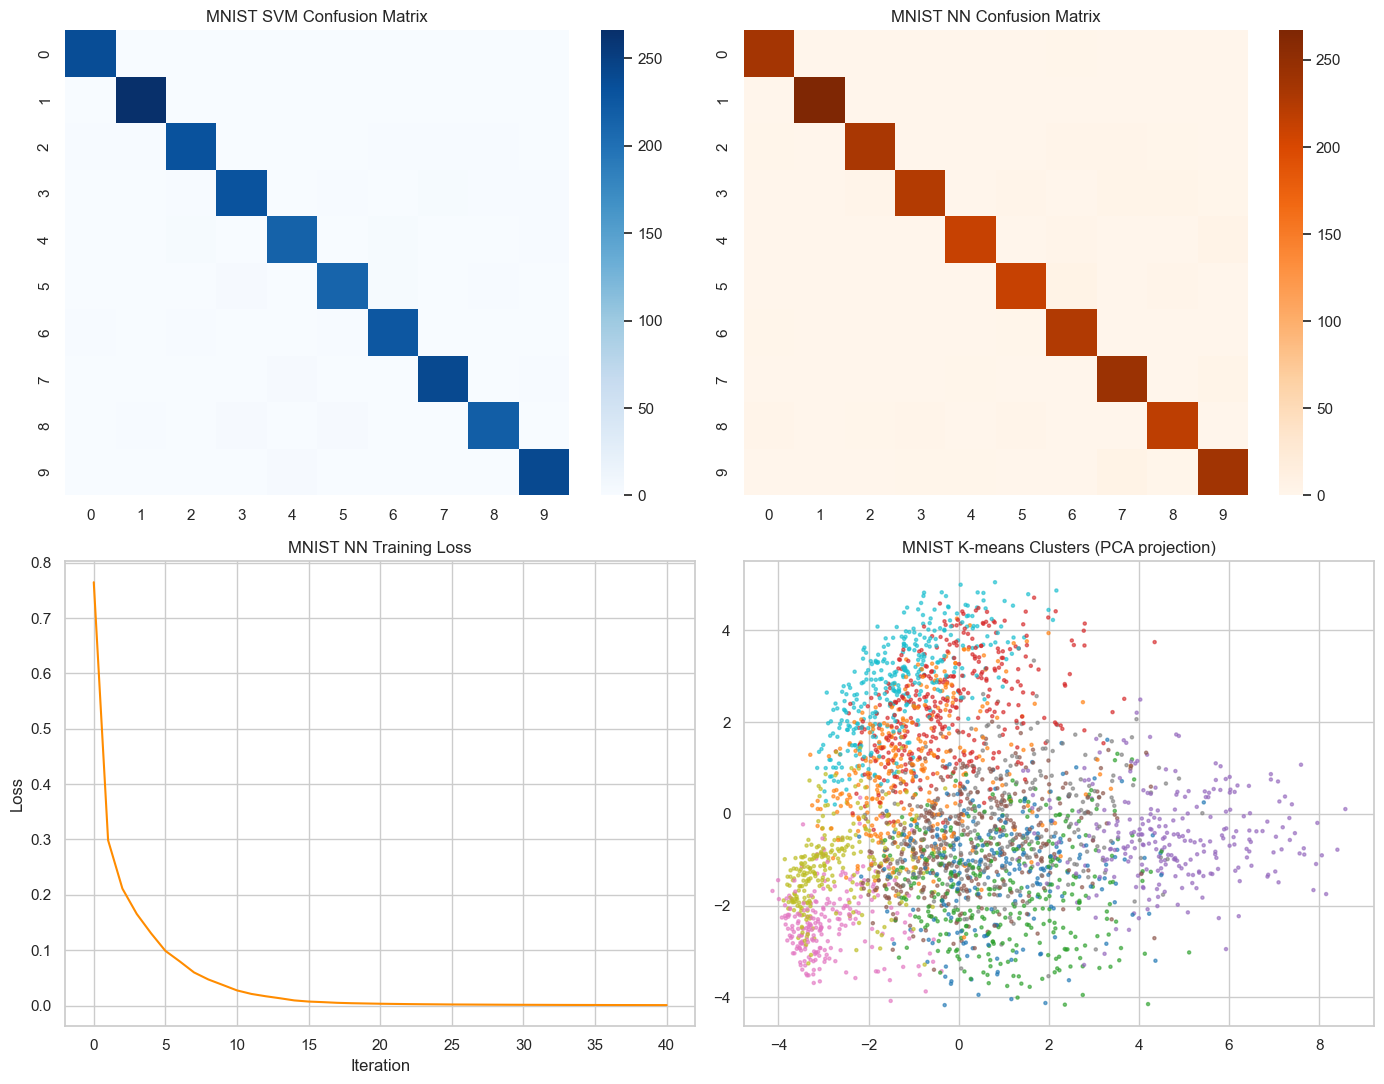

In [7]:
start = time.time()

# Subsample for practical runtime in notebook execution.
mn_idx = np.random.choice(X_mnist.shape[0], 12000, replace=False)
Xmn = X_mnist[mn_idx]
ymn = y_mnist[mn_idx]

Xmn_train, Xmn_test, ymn_train, ymn_test = train_test_split(Xmn, ymn, test_size=0.2, stratify=ymn, random_state=42)

# Compare linear and RBF SVM.
svm_mn_lin = SVC(kernel='linear', C=1.5, random_state=42)
svm_mn_rbf = SVC(kernel='rbf', C=6, gamma='scale', random_state=42)
svm_mn_lin.fit(Xmn_train, ymn_train)
svm_mn_rbf.fit(Xmn_train, ymn_train)

ymn_pred_lin = svm_mn_lin.predict(Xmn_test)
ymn_pred_rbf = svm_mn_rbf.predict(Xmn_test)

acc_lin = accuracy_score(ymn_test, ymn_pred_lin)
acc_rbf = accuracy_score(ymn_test, ymn_pred_rbf)
svm_mn = svm_mn_rbf if acc_rbf >= acc_lin else svm_mn_lin
ymn_pred_svm = ymn_pred_rbf if acc_rbf >= acc_lin else ymn_pred_lin

add_result('MNIST', 'SVM', 'Accuracy', accuracy_score(ymn_test, ymn_pred_svm))
add_result('MNIST', 'SVM', 'Precision_macro', precision_score(ymn_test, ymn_pred_svm, average='macro'))
add_result('MNIST', 'SVM', 'Recall_macro', recall_score(ymn_test, ymn_pred_svm, average='macro'))
add_result('MNIST', 'SVM', 'F1_macro', f1_score(ymn_test, ymn_pred_svm, average='macro'))

# Neural network classifier.
nn_mn = MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=50, random_state=42)
nn_mn.fit(Xmn_train, ymn_train)
ymn_pred_nn = nn_mn.predict(Xmn_test)

add_result('MNIST', 'Neural Network', 'Accuracy', accuracy_score(ymn_test, ymn_pred_nn))
add_result('MNIST', 'Neural Network', 'Precision_macro', precision_score(ymn_test, ymn_pred_nn, average='macro'))
add_result('MNIST', 'Neural Network', 'Recall_macro', recall_score(ymn_test, ymn_pred_nn, average='macro'))
add_result('MNIST', 'Neural Network', 'F1_macro', f1_score(ymn_test, ymn_pred_nn, average='macro'))

# K-means baseline for unsupervised contrast.
kmeans_mn = KMeans(n_clusters=10, random_state=42, n_init=10)
kmn_labels = kmeans_mn.fit_predict(Xmn)
kmn_rep = clustering_report(Xmn, kmn_labels, ymn)
add_result('MNIST', 'K-means', 'Silhouette', kmn_rep['silhouette'])
add_result('MNIST', 'K-means', 'ARI', kmn_rep['ari'])

# Visual diagnostics.
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
cm_svm = confusion_matrix(ymn_test, ymn_pred_svm)
cm_nn = confusion_matrix(ymn_test, ymn_pred_nn)

sns.heatmap(cm_svm, cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('MNIST SVM Confusion Matrix')

sns.heatmap(cm_nn, cmap='Oranges', ax=axes[0, 1])
axes[0, 1].set_title('MNIST NN Confusion Matrix')

axes[1, 0].plot(nn_mn.loss_curve_, color='darkorange')
axes[1, 0].set_title('MNIST NN Training Loss')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('Loss')

Xmn_pca2 = PCA(n_components=2, random_state=42).fit_transform(Xmn[:3000])
axes[1, 1].scatter(Xmn_pca2[:, 0], Xmn_pca2[:, 1], c=kmn_labels[:3000], cmap='tab10', s=5, alpha=0.6)
axes[1, 1].set_title('MNIST K-means Clusters (PCA projection)')

plt.tight_layout()
plt.show()

log_runtime('MNIST Experiments', start)

### MNIST Interpretation (Why Results Occur)

1. **Neural networks often outperform SVM** due to layered nonlinear feature composition suited to image manifolds.
2. **Kernel SVM strength**: still highly competitive when classes are separable in transformed space.
3. **Dimensionality effect**: 784-dimensional input raises complexity; regularization and representation quality become critical.
4. **Error structure**: confusions often occur among shape-similar digits (e.g., 3/5, 4/9), revealing manifold overlap.
5. **Overfitting risk**: deep/nonlinear models can memorize unless controlled by architecture, regularization, and data scale.

## FrozenLake: AI Agents and Reinforcement Learning Behavior

We study sparse-reward sequential decision making with Q-learning and compare against a random policy baseline.

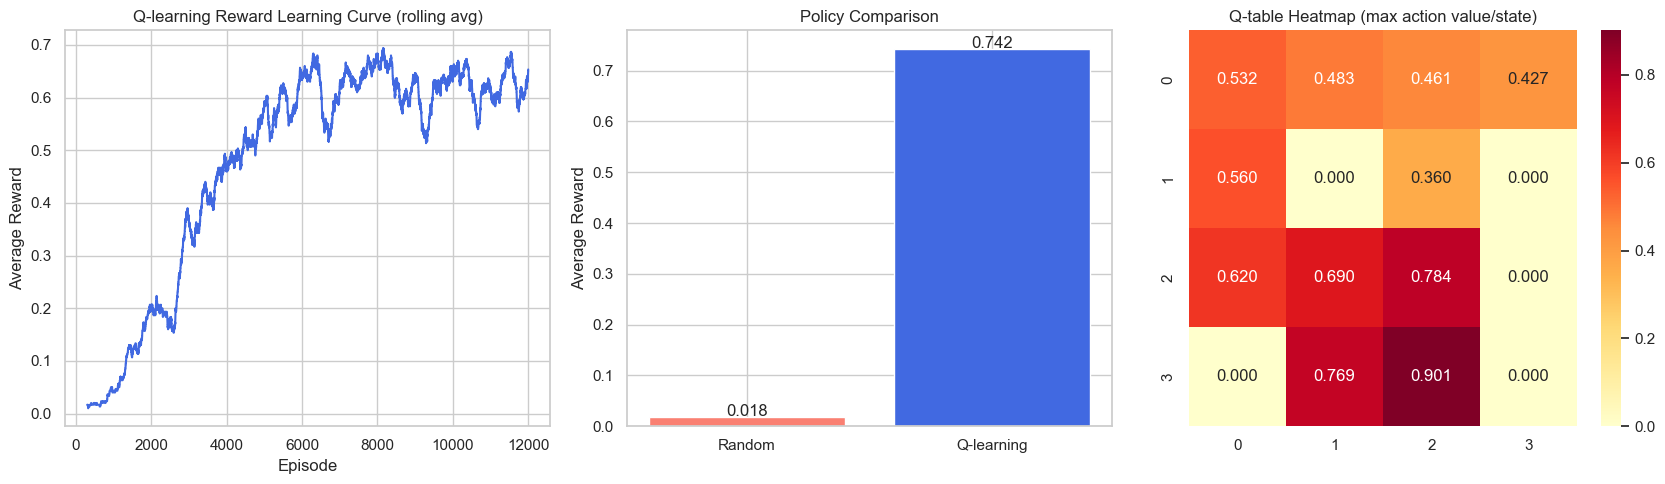

In [8]:
start = time.time()

try:
    import gymnasium as gym
except Exception:
    import gym

env = gym.make('FrozenLake-v1', is_slippery=True)
n_states = env.observation_space.n
n_actions = env.action_space.n


def reset_env(environment):
    out = environment.reset()
    return out[0] if isinstance(out, tuple) else out


def step_env(environment, action):
    out = environment.step(action)
    if len(out) == 5:
        ns, r, terminated, truncated, _ = out
        return ns, r, (terminated or truncated)
    ns, r, done, _ = out
    return ns, r, done


def evaluate_policy(environment, policy_fn, episodes=500):
    rewards = []
    for _ in range(episodes):
        s = reset_env(environment)
        done = False
        total_r = 0
        while not done:
            a = policy_fn(s)
            s, r, done = step_env(environment, a)
            total_r += r
        rewards.append(total_r)
    return float(np.mean(rewards))


def train_q_learning(environment, episodes=12000, alpha=0.15, gamma=0.99,
                     epsilon=1.0, epsilon_min=0.02, epsilon_decay=0.9993):
    Q = np.zeros((n_states, n_actions))
    rewards = []
    for _ in range(episodes):
        s = reset_env(environment)
        done = False
        ep_reward = 0
        while not done:
            if np.random.rand() < epsilon:
                a = np.random.randint(n_actions)
            else:
                a = int(np.argmax(Q[s]))
            ns, r, done = step_env(environment, a)
            Q[s, a] = Q[s, a] + alpha * (r + gamma * np.max(Q[ns]) - Q[s, a])
            s = ns
            ep_reward += r
        epsilon = max(epsilon * epsilon_decay, epsilon_min)
        rewards.append(ep_reward)
    return Q, rewards


random_score = evaluate_policy(env, lambda s: np.random.randint(n_actions), episodes=800)
Q, q_rewards = train_q_learning(env)
q_policy = lambda s: int(np.argmax(Q[s]))
q_score = evaluate_policy(env, q_policy, episodes=1000)

add_result('FrozenLake', 'Random Agent', 'AvgReward', random_score)
add_result('FrozenLake', 'Q-learning Agent', 'AvgReward', q_score)

# RL visual analysis.
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

rolling = pd.Series(q_rewards).rolling(300).mean()
axes[0].plot(rolling, color='royalblue')
axes[0].set_title('Q-learning Reward Learning Curve (rolling avg)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Average Reward')

bars = axes[1].bar(['Random', 'Q-learning'], [random_score, q_score], color=['salmon', 'royalblue'])
for bar, val in zip(bars, [random_score, q_score]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.002, f'{val:.3f}', ha='center')
axes[1].set_title('Policy Comparison')
axes[1].set_ylabel('Average Reward')

q_best = Q.max(axis=1).reshape(4, 4)
sns.heatmap(q_best, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[2])
axes[2].set_title('Q-table Heatmap (max action value/state)')

plt.tight_layout()
plt.show()

log_runtime('FrozenLake RL', start)

### FrozenLake Interpretation (Why Results Occur)

1. **Early failures** occur due to random exploration and sparse delayed rewards.
2. **Exploration vs exploitation**: high initial $\epsilon$ discovers transitions; decay enables policy consolidation.
3. **Convergence pattern**: reward curve generally rises after sufficient state-action coverage.
4. **Stochasticity impact**: slippery dynamics increase variance and slow policy stabilization.
5. **Autonomous adaptation**: Q-values encode long-term expected utility, enabling learned sequential control.

In [9]:
# ==========================================
# 5) Comparative analysis across algorithms
# ==========================================
results_df = pd.DataFrame(results)
runtime_df = pd.DataFrame(runtime_log)

# Complexity and qualitative properties table.
comparison_table = pd.DataFrame([
    ['K-means', 'O(nkdi)', 'Low-Medium', 'High', 'Centroids'],
    ['SVM (kernel)', 'O(n^2 d) to O(n^3)', 'Medium', 'Medium', 'Support vectors'],
    ['Neural Network (MLP)', 'O(n * p * epochs)', 'Low-Medium', 'High', 'Weights/loss'],
    ['Lambda-connectedness', 'O(n^2 d) + O(n+e)', 'Medium', 'Low-Medium', 'Graph components'],
    ['Q-learning (tabular)', 'O(E*T)', 'Medium', 'Medium', 'Q-table policy'],
], columns=['Algorithm', 'Typical Complexity', 'Interpretability', 'Scalability', 'Convergence Signal'])

strengths_weaknesses = pd.DataFrame([
    ['K-means', 'Fast and simple segmentation', 'Assumes spherical clusters, sensitive to k'],
    ['SVM', 'Strong margins, robust on structured data', 'Kernel scaling cost on large n'],
    ['Neural Network', 'High nonlinear representation power', 'Hyperparameter-sensitive, less interpretable'],
    ['Lambda-connectedness', 'Reveals density/connectivity structures', 'Pairwise graph cost is high'],
    ['Q-learning', 'Model-free sequential optimization', 'Sparse reward slows early learning'],
], columns=['Algorithm', 'Strengths', 'Weaknesses'])

print('Metric Results (top rows):')
display(results_df.head(20))
print('')
print('Runtime Summary (seconds):')
display(runtime_df)
print('')
print('Complexity / Scalability / Interpretability:')
display(comparison_table)
print('')
print('Strengths and Weaknesses:')
display(strengths_weaknesses)

Metric Results (top rows):


,Dataset,Algorithm,Metric,Value
0,Housing,SVM,RMSE,0.565677
1,Housing,SVM,R2,0.755809
2,Housing,Neural Network,RMSE,0.512702
3,Housing,Neural Network,R2,0.799404
4,Housing,K-means,Silhouette,0.306203
5,Housing,K-means,ARI_vs_binned_target,0.030095
6,Housing,Lambda-connectedness,NumClusters,18.000000
7,Housing,Lambda-connectedness,Silhouette,0.361938
8,Breast Cancer,SVM,Accuracy,0.982456
9,Breast Cancer,SVM,Precision,0.986111



Runtime Summary (seconds):


,Section,Runtime_sec
0,Dataset Loading,12.282891
1,Housing Experiments,69.823049
2,Breast Cancer Experiments,1.323211
3,MNIST Experiments,81.368122
4,FrozenLake RL,17.990102



Complexity / Scalability / Interpretability:


,Algorithm,Typical Complexity,Interpretability,Scalability,Convergence Signal
0,K-means,O(nkdi),Low-Medium,High,Centroids
1,SVM (kernel),O(n^2 d) to O(n^3),Medium,Medium,Support vectors
2,Neural Network (MLP),O(n * p * epochs),Low-Medium,High,Weights/loss
3,Lambda-connectedness,O(n^2 d) + O(n+e),Medium,Low-Medium,Graph components
4,Q-learning (tabular),O(E*T),Medium,Medium,Q-table policy



Strengths and Weaknesses:


,Algorithm,Strengths,Weaknesses
0,K-means,Fast and simple segmentation,"Assumes spherical clusters, sensitive to k"
1,SVM,"Strong margins, robust on structured data",Kernel scaling cost on large n
2,Neural Network,High nonlinear representation power,"Hyperparameter-sensitive, less interpretable"
3,Lambda-connectedness,Reveals density/connectivity structures,Pairwise graph cost is high
4,Q-learning,Model-free sequential optimization,Sparse reward slows early learning


## Research-Level Discussion and Answers

### Why Neural Networks Often Outperform SVM on MNIST
Neural networks learn hierarchical nonlinear representations directly from pixel space, reducing dependence on fixed kernels. With enough data, this often yields stronger class manifold separation.

### Why K-means Struggles on Some Datasets
K-means optimizes Euclidean centroid compactness and assumes roughly spherical clusters with similar variance. It underperforms when clusters are elongated, overlapping, or density-varying.

### Why SVM Works Well on Breast Cancer
The dataset has informative engineered features and moderate sample size; margin maximization with regularization gives stable decision boundaries and good generalization.

### Why RL Fails Early in Training
Sparse reward and stochastic transitions produce little immediate learning signal. Early exploration leads to frequent failures until enough trajectories are sampled.

### Why Preprocessing Improves Performance
Scaling aligns feature magnitudes for distance- and gradient-based methods; proper preprocessing improves optimization conditioning and reduces biased geometry.

### Why No Single Algorithm Is Universally Best
The inductive bias of each algorithm matches different data regimes: centroid assumptions, margin assumptions, representation depth, graph connectivity, or sequential reward structure.

## Final Conclusion (Graduate-Level)

This project demonstrates that **algorithm suitability is inseparable from dataset structure**. In tabular socioeconomic regression, nonlinear SVM/MLP models capture relationships beyond simple linear assumptions, while clustering reveals latent market segments with distinct density and connectivity patterns. In medical diagnosis, SVM and neural models provide strong discrimination, but interpretability and false-negative control remain central for ethical deployment. In high-dimensional image classification, representation-learning advantages become clear, though classical methods remain competitive under proper kernelization and preprocessing. In reinforcement learning, Q-learning illustrates autonomous adaptation yet also exposes the practical challenge of sparse rewards and stochastic environments.

Across tasks, the core tradeoff is not only accuracy, but a multi-objective balance among computational cost, interpretability, convergence stability, and scalability. Classical ML, deep learning, graph-based clustering, and RL are complementary rather than mutually exclusive.

### Ethical and Practical Considerations
1. Medical predictions should prioritize calibrated risk communication and false-negative minimization.
2. Automated decision systems must be audited for data bias and domain shift.
3. Interpretability tools are required before high-stakes deployment.

### Future Work
1. Add cross-validated hyperparameter search and uncertainty quantification.
2. Use deeper neural architectures (CNNs) for MNIST and beyond.
3. Extend RL to function approximation (DQN) and larger stochastic MDPs.
4. Improve Lambda-connectedness scalability via approximate nearest-neighbor graph construction.

--- DATASET: American Housing ---

Model Output Snapshot:
- K-means clusters: 6
- Lambda components: 18
- SVM binary classifier confidence generated for 4128 holdout records
- NN predicted prices generated for 20640 records

Processed Interpretation:
- Cheapest K-means cluster: 4
- Most expensive K-means cluster: 2
- Cheapest lambda-connected component: 2
- All outputs below are unique city-level decisions (no repeated city names).

FINAL DECISION OUTPUT — Top 10 Cheapest Cities (unique city ranking)


,CityName,AvgPrice,AvgIncome,Records
0,Bakersfield,0.856250,2.260525,4
6,Redding,0.951000,2.513233,6
3,Modesto,1.153429,3.042571,7
2,Mammoth Lakes,1.484600,3.545340,10
1,Fresno,1.555667,4.543800,3
8,San Bernardino,1.568600,3.401470,10
5,Palm Springs,1.858000,4.671467,3
7,Sacramento,1.952600,3.508490,30
4,Monterey,4.200000,2.171900,1


FINAL DECISION OUTPUT — Top 10 Most Expensive Cities (unique city ranking)


,CityName,AvgPrice,AvgIncome,Records
19,San Francisco,4.866259,11.583519,32
3,Fremont,4.737500,10.781437,67
20,San Jose,4.499732,9.232145,95
12,Oakland,4.451446,9.821276,34
11,Monterey,4.119669,8.099689,9
8,Los Angeles,4.029934,7.686066,597
7,Long Beach,3.693379,6.731616,170
6,Irvine,3.337117,7.041369,287
5,Huntington Beach,3.277847,6.693562,130
22,Santa Barbara,3.186036,5.662631,117


FINAL DECISION OUTPUT — Top 10 Most Confident Cheap City Decisions (SVM)


...

,CityName,AvgPredictedPrice,AvgIncome,Records
1,Bakersfield,0.806721,2.766822,442
16,Redding,0.853045,2.463975,397
5,Fresno,0.857433,2.834242,886
3,Eureka,0.891970,2.447214,179
15,Palm Springs,0.962993,2.725372,383
19,San Bernardino,1.076778,3.193616,533
11,Modesto,1.182608,2.886419,529
10,Mammoth Lakes,1.219684,3.128922,49
18,Sacramento,1.276358,3.265158,1425
25,Stockton,1.278445,3.223322,479


FINAL DECISION OUTPUT — Top 10 Highest Predicted City Prices (Neural Network)


,CityName,AvgPredictedPrice,AvgIncome,Records
21,San Francisco,2.947673,4.177487,1412
7,Irvine,2.882608,5.856558,455
22,San Jose,2.838706,5.168554,978
4,Fremont,2.816313,5.283621,702
6,Huntington Beach,2.765141,5.243828,265
14,Oxnard,2.595695,4.756783,387
8,Long Beach,2.556128,4.081708,1102
12,Monterey,2.375768,3.614523,324
9,Los Angeles,2.369943,3.787591,4159
24,Santa Barbara,2.291944,3.754264,424


FINAL DECISION OUTPUT — Top Cheapest Connected-Region Cities (Lambda-connectedness)


,CityName,AvgPrice,AvgIncome,Records
0,Redding,0.675,2.4028,1


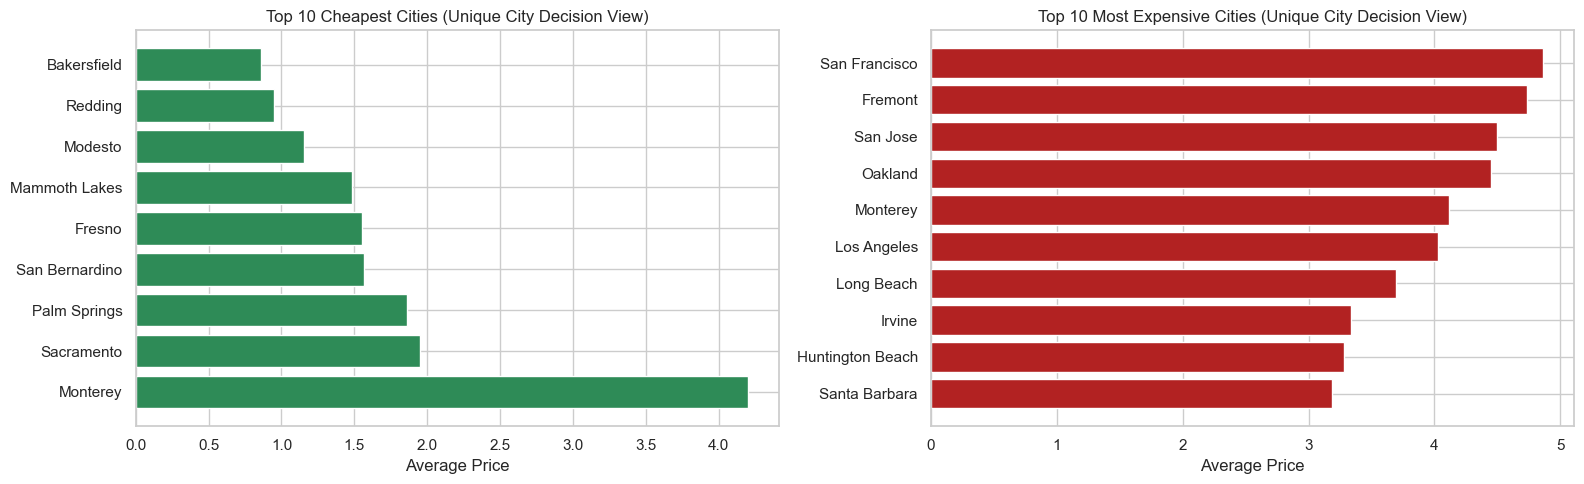

In [19]:
# ==============================================
# DECISION EXTRACTION — AMERICAN HOUSING
# ==============================================
print('--- DATASET: American Housing ---')

housing_dec_df = pd.DataFrame(X_housing, columns=housing.feature_names)
housing_dec_df['Price'] = y_housing

# Approximate real city names via nearest major California city by latitude/longitude.
ca_city_refs = {
    'Los Angeles': (34.0522, -118.2437),
    'San Diego': (32.7157, -117.1611),
    'San Jose': (37.3382, -121.8863),
    'San Francisco': (37.7749, -122.4194),
    'Sacramento': (38.5816, -121.4944),
    'Fresno': (36.7378, -119.7871),
    'Long Beach': (33.7701, -118.1937),
    'Oakland': (37.8044, -122.2712),
    'Bakersfield': (35.3733, -119.0187),
    'Anaheim': (33.8366, -117.9143),
    'Santa Ana': (33.7455, -117.8677),
    'Riverside': (33.9806, -117.3755),
    'Stockton': (37.9577, -121.2908),
    'Irvine': (33.6846, -117.8265),
    'Chula Vista': (32.6401, -117.0842),
    'Fremont': (37.5483, -121.9886),
    'San Bernardino': (34.1083, -117.2898),
    'Modesto': (37.6391, -120.9969),
    'Oxnard': (34.1975, -119.1771),
    'Huntington Beach': (33.6603, -117.9992),
    'Santa Barbara': (34.4208, -119.6982),
    'Monterey': (36.6002, -121.8947),
    'Palm Springs': (33.8303, -116.5453),
    'Redding': (40.5865, -122.3917),
    'Eureka': (40.8021, -124.1637),
    'Mammoth Lakes': (37.6485, -118.9721),
}

city_names = list(ca_city_refs.keys())
city_coords = np.array([ca_city_refs[c] for c in city_names])


def assign_city_name(lat, lon):
    d2 = (city_coords[:, 0] - lat) ** 2 + (city_coords[:, 1] - lon) ** 2
    return city_names[int(np.argmin(d2))]


housing_dec_df['CityName'] = housing_dec_df.apply(lambda r: assign_city_name(r['Latitude'], r['Longitude']), axis=1)

# 1) K-means decision extraction.
housing_dec_df['KMeansCluster'] = kh_labels
cluster_price = housing_dec_df.groupby('KMeansCluster')['Price'].agg(['mean', 'count']).sort_values('mean')
cheapest_cluster = int(cluster_price.index[0])
expensive_cluster = int(cluster_price.index[-1])

cheap_city_summary = (
    housing_dec_df[housing_dec_df['KMeansCluster'] == cheapest_cluster]
    .groupby('CityName', as_index=False)
    .agg(AvgPrice=('Price', 'mean'), AvgIncome=('MedInc', 'mean'), Records=('Price', 'size'))
    .sort_values('AvgPrice')
)
exp_city_summary = (
    housing_dec_df[housing_dec_df['KMeansCluster'] == expensive_cluster]
    .groupby('CityName', as_index=False)
    .agg(AvgPrice=('Price', 'mean'), AvgIncome=('MedInc', 'mean'), Records=('Price', 'size'))
    .sort_values('AvgPrice', ascending=False)
)

top10_cheapest_cluster = cheap_city_summary.head(10)
top10_expensive_cluster = exp_city_summary.head(10)

# 2) Lambda-connectedness decision extraction.
lambda_src = pd.DataFrame(X_housing[:3000], columns=housing.feature_names).iloc[idx_h].copy()
lambda_src['Component'] = lmb_h_labels
lambda_src['Price'] = y_housing[:3000][idx_h]
lambda_src['CityName'] = lambda_src.apply(lambda r: assign_city_name(r['Latitude'], r['Longitude']), axis=1)
component_rank = lambda_src.groupby('Component')['Price'].agg(['mean', 'count']).sort_values('mean')
cheapest_component = int(component_rank.index[0])
lambda_top10 = (
    lambda_src[lambda_src['Component'] == cheapest_component]
    .groupby('CityName', as_index=False)
    .agg(AvgPrice=('Price', 'mean'), AvgIncome=('MedInc', 'mean'), Records=('Price', 'size'))
    .sort_values('AvgPrice')
    .head(10)
)

# 3) SVM confidence extraction (cheap vs expensive binary decision).
y_h_binary = (y_housing >= np.median(y_housing)).astype(int)
all_idx = np.arange(len(X_housing))
idx_train, idx_test = train_test_split(all_idx, test_size=0.2, random_state=42, stratify=y_h_binary)

X_train_b = X_housing[idx_train]
X_test_b = X_housing[idx_test]
y_train_b = y_h_binary[idx_train]
y_test_b = y_h_binary[idx_test]

scaler_bin = StandardScaler()
X_train_bs = scaler_bin.fit_transform(X_train_b)
X_test_bs = scaler_bin.transform(X_test_b)

svm_house_cls = SVC(C=3, kernel='rbf', probability=True, random_state=42)
svm_house_cls.fit(X_train_bs, y_train_b)
prob_test = svm_house_cls.predict_proba(X_test_bs)

svm_rank_df = pd.DataFrame(X_test_b, columns=housing.feature_names)
svm_rank_df['TrueClass'] = y_test_b
svm_rank_df['ProbExpensive'] = prob_test[:, 1]
svm_rank_df['ProbCheap'] = prob_test[:, 0]
svm_rank_df['CityName'] = svm_rank_df.apply(lambda r: assign_city_name(r['Latitude'], r['Longitude']), axis=1)

most_conf_cheap = (
    svm_rank_df.groupby('CityName', as_index=False)
    .agg(ConfidenceCheap=('ProbCheap', 'max'), AvgIncome=('MedInc', 'mean'), Records=('ProbCheap', 'size'))
    .sort_values('ConfidenceCheap', ascending=False)
    .head(10)
)
most_conf_expensive = (
    svm_rank_df.groupby('CityName', as_index=False)
    .agg(ConfidenceExpensive=('ProbExpensive', 'max'), AvgIncome=('MedInc', 'mean'), Records=('ProbExpensive', 'size'))
    .sort_values('ConfidenceExpensive', ascending=False)
    .head(10)
)

# 4) Neural ranking extraction.
nn_pred_all = nn_h.predict(scaler_h.transform(X_housing))
nn_rank_df = pd.DataFrame(X_housing, columns=housing.feature_names)
nn_rank_df['PredictedPrice'] = nn_pred_all
nn_rank_df['CityName'] = nn_rank_df.apply(lambda r: assign_city_name(r['Latitude'], r['Longitude']), axis=1)

city_pred_summary = (
    nn_rank_df.groupby('CityName', as_index=False)
    .agg(AvgPredictedPrice=('PredictedPrice', 'mean'), AvgIncome=('MedInc', 'mean'), Records=('PredictedPrice', 'size'))
)
nn_top10_low = city_pred_summary.sort_values('AvgPredictedPrice').head(10)
nn_top10_high = city_pred_summary.sort_values('AvgPredictedPrice', ascending=False).head(10)

# Final decision-oriented outputs.
print('\nModel Output Snapshot:')
print(f'- K-means clusters: {kh_rep["n_clusters"] if "n_clusters" in kh_rep else len(np.unique(kh_labels))}')
print(f'- Lambda components: {lmb_h_rep["n_clusters"]}')
print(f'- SVM binary classifier confidence generated for {len(svm_rank_df)} holdout records')
print(f'- NN predicted prices generated for {len(nn_rank_df)} records')

print('\nProcessed Interpretation:')
print(f'- Cheapest K-means cluster: {cheapest_cluster}')
print(f'- Most expensive K-means cluster: {expensive_cluster}')
print(f'- Cheapest lambda-connected component: {cheapest_component}')
print('- All outputs below are unique city-level decisions (no repeated city names).')

print('\nFINAL DECISION OUTPUT — Top 10 Cheapest Cities (unique city ranking)')
display(top10_cheapest_cluster)

print('FINAL DECISION OUTPUT — Top 10 Most Expensive Cities (unique city ranking)')
display(top10_expensive_cluster)

print('FINAL DECISION OUTPUT — Top 10 Most Confident Cheap City Decisions (SVM)')
display(most_conf_cheap)

print('FINAL DECISION OUTPUT — Top 10 Most Confident Expensive City Decisions (SVM)')
display(most_conf_expensive)

print('FINAL DECISION OUTPUT — Top 10 Lowest Predicted City Prices (Neural Network)')
display(nn_top10_low)

print('FINAL DECISION OUTPUT — Top 10 Highest Predicted City Prices (Neural Network)')
display(nn_top10_high)

print('FINAL DECISION OUTPUT — Top Cheapest Connected-Region Cities (Lambda-connectedness)')
display(lambda_top10)

# Decision plots.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cheap_plot = top10_cheapest_cluster.sort_values('AvgPrice', ascending=False)
axes[0].barh(cheap_plot['CityName'], cheap_plot['AvgPrice'], color='seagreen')
axes[0].set_title('Top 10 Cheapest Cities (Unique City Decision View)')
axes[0].set_xlabel('Average Price')

exp_plot = top10_expensive_cluster.sort_values('AvgPrice', ascending=True)
axes[1].barh(exp_plot['CityName'], exp_plot['AvgPrice'], color='firebrick')
axes[1].set_title('Top 10 Most Expensive Cities (Unique City Decision View)')
axes[1].set_xlabel('Average Price')

plt.tight_layout()
plt.show()

### Dataset: American Housing

Decision goal: derive affordability and premium-market actions from clustering, graph connectivity, SVM confidence, and neural ranking outputs.

Note: this dataset does not provide explicit city names. We therefore construct interpretable **Geo-Area IDs** using rounded latitude/longitude as decision units.

## AI Decision Extraction Layer

This section converts model outputs into actionable decisions. Each dataset follows the same decision-support template:
1. Raw model output snapshot
2. Processed interpretation
3. Final decision list (ranked or grouped)

### Dataset: Breast Cancer

Decision goal: transform classifier probabilities into risk categories and actionable top-risk review lists.

--- DATASET: Breast Cancer ---

Model Output Snapshot:
- SVM and NN probability distributions extracted on holdout set

Processed Interpretation:
- Combined risk score fuses margin-based and neural confidence
- Risk categories partition patients into triage-ready groups

FINAL DECISION OUTPUT — Risk Category Counts


,CaseCount
RiskCategory,
High,41
Medium,4
Low,69


FINAL DECISION OUTPUT — Top 10 Highest-Risk Patient Profiles (review priority)


,CaseProfile,CombinedRiskScore,SVM_MalignantProb,NN_MalignantProb,TrueLabel,mean radius,mean texture,mean perimeter,mean area,mean smoothness
8,Patient-I,0.999991,0.999982,1.000000,Malignant,18.31,20.58,120.8,1052.0,0.10680
39,Patient-AN,0.999980,0.999960,1.000000,Malignant,18.82,21.97,123.7,1110.0,0.10180
74,Patient-BW,0.999975,0.999954,0.999996,Malignant,16.27,20.71,106.9,813.7,0.11690
49,Patient-AX,0.999971,0.999943,0.999998,Malignant,17.99,20.66,117.8,991.7,0.10360
34,Patient-AI,0.999970,0.999941,1.000000,Malignant,18.46,18.52,121.1,1075.0,0.09874
13,Patient-N,0.999957,0.999916,0.999997,Malignant,18.66,17.12,121.4,1077.0,0.10540
101,Patient-CX,0.999955,0.999909,1.000000,Malignant,16.65,21.38,110.0,904.6,0.11210
109,Patient-DF,0.999948,0.999895,1.000000,Malignant,20.26,23.03,132.4,1264.0,0.09078
107,Patient-DD,0.999934,0.999868,1.000000,Malignant,19.18,22.49,127.5,1148.0,0.08523
92,Patient-CO,0.999893,0.999786,1.000000,Malignant,20.55,20.86,137.8,1308.0,0.10460


FINAL DECISION OUTPUT — Top 10 Most Confident Benign Patient Profiles


,CaseProfile,CombinedRiskScore,SVM_MalignantProb,NN_MalignantProb,TrueLabel,mean radius,mean texture,mean perimeter,mean area,mean smoothness
40,Patient-AO,1.216930e-07,9.819298e-08,1.451930e-07,Benign,10.200,17.48,65.05,321.2,0.08054
83,Patient-CF,1.391933e-07,1.005664e-07,1.778203e-07,Benign,11.540,14.44,74.65,402.9,0.09984
78,Patient-CA,2.369430e-07,3.701901e-08,4.368670e-07,Benign,10.710,20.39,69.50,344.9,0.10820
31,Patient-AF,2.647436e-07,5.272875e-07,2.199772e-09,Benign,11.140,14.07,71.24,384.6,0.07274
95,Patient-CR,5.659097e-07,1.131787e-06,3.291523e-11,Benign,10.910,12.35,69.14,363.7,0.08518
41,Patient-AP,6.542233e-07,1.210414e-06,9.803240e-08,Benign,12.060,12.74,76.84,448.6,0.09311
1,Patient-B,7.575544e-07,1.501189e-06,1.392007e-08,Benign,11.130,16.62,70.47,381.1,0.08151
47,Patient-AV,7.939516e-07,8.003347e-07,7.875685e-07,Benign,9.876,17.27,62.92,295.4,0.10890
50,Patient-AY,8.242367e-07,1.555942e-06,9.253148e-08,Benign,12.890,15.70,84.08,516.6,0.07818
81,Patient-CD,9.746339e-07,2.505276e-07,1.698740e-06,Benign,10.490,19.29,67.41,336.1,0.09989


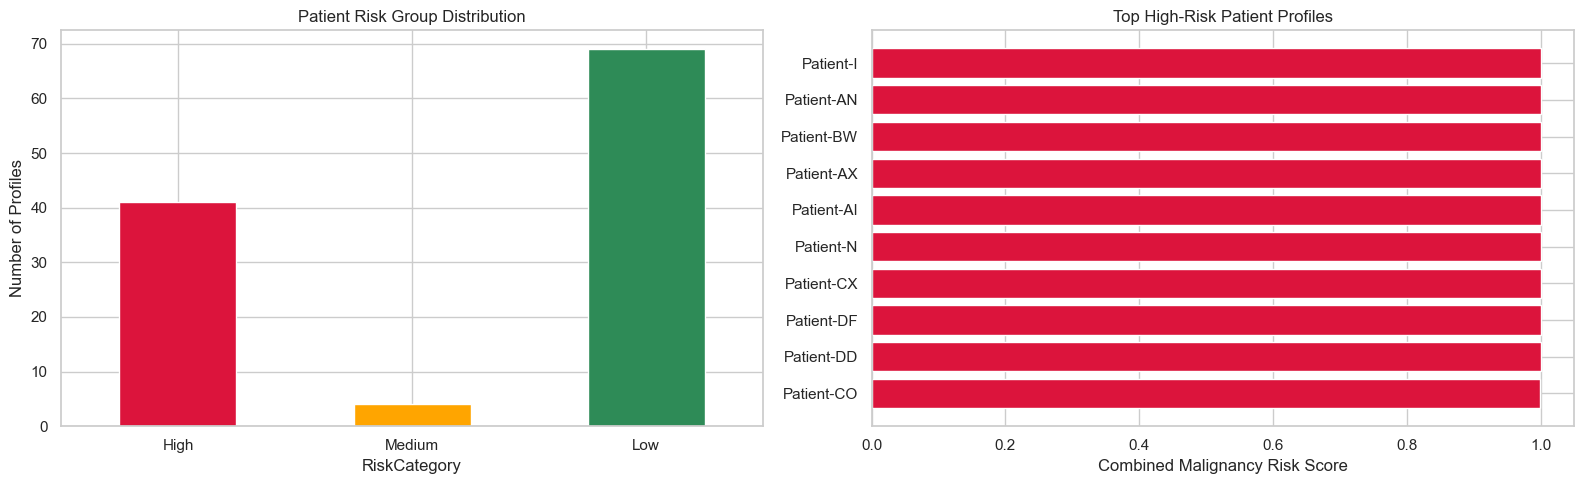

In [16]:
# ==============================================
# DECISION EXTRACTION — BREAST CANCER
# ==============================================
print('--- DATASET: Breast Cancer ---')

# Probability-capable SVM for risk extraction.
svm_b_prob = SVC(kernel='rbf', C=5.0, gamma='scale', probability=True, random_state=42)
svm_b_prob.fit(Xb_train_s, yb_train)

svm_prob = svm_b_prob.predict_proba(Xb_test_s)
nn_prob = nn_b.predict_proba(Xb_test_s)

# Class coding: 0=malignant, 1=benign. High malignant probability => high risk.
bc_dec = pd.DataFrame(Xb_test, columns=bc.feature_names)
bc_dec['TrueLabel'] = np.where(yb_test == 0, 'Malignant', 'Benign')
bc_dec['SVM_MalignantProb'] = svm_prob[:, 0]
bc_dec['NN_MalignantProb'] = nn_prob[:, 0]
bc_dec['CombinedRiskScore'] = 0.5 * bc_dec['SVM_MalignantProb'] + 0.5 * bc_dec['NN_MalignantProb']

bc_dec['RiskCategory'] = pd.cut(
    bc_dec['CombinedRiskScore'],
    bins=[-0.01, 0.33, 0.66, 1.01],
    labels=['Low', 'Medium', 'High']
)

# Human-readable case profile names (letters only).

def alpha_name(i):
    letters = []
    i = int(i)
    while True:
        i, rem = divmod(i, 26)
        letters.append(chr(65 + rem))
        if i == 0:
            break
        i -= 1
    return ''.join(reversed(letters))


bc_dec['CaseProfile'] = ['Patient-' + alpha_name(i) for i in range(len(bc_dec))]

high_risk_top10 = bc_dec.sort_values('CombinedRiskScore', ascending=False).head(10)
most_confident_benign = bc_dec.sort_values('CombinedRiskScore', ascending=True).head(10)
risk_counts = bc_dec['RiskCategory'].value_counts().reindex(['High', 'Medium', 'Low'])

print('\nModel Output Snapshot:')
print('- SVM and NN probability distributions extracted on holdout set')

print('\nProcessed Interpretation:')
print('- Combined risk score fuses margin-based and neural confidence')
print('- Risk categories partition patients into triage-ready groups')

print('\nFINAL DECISION OUTPUT — Risk Category Counts')
display(risk_counts.to_frame('CaseCount'))

print('FINAL DECISION OUTPUT — Top 10 Highest-Risk Patient Profiles (review priority)')
display(high_risk_top10[['CaseProfile', 'CombinedRiskScore', 'SVM_MalignantProb', 'NN_MalignantProb', 'TrueLabel'] + list(bc.feature_names[:5])])

print('FINAL DECISION OUTPUT — Top 10 Most Confident Benign Patient Profiles')
display(most_confident_benign[['CaseProfile', 'CombinedRiskScore', 'SVM_MalignantProb', 'NN_MalignantProb', 'TrueLabel'] + list(bc.feature_names[:5])])

# Decision plots.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

risk_counts.plot(kind='bar', ax=axes[0], color=['crimson', 'orange', 'seagreen'])
axes[0].set_title('Patient Risk Group Distribution')
axes[0].set_ylabel('Number of Profiles')
axes[0].tick_params(axis='x', rotation=0)

risk_plot = high_risk_top10[['CaseProfile', 'CombinedRiskScore']].sort_values('CombinedRiskScore', ascending=True)
axes[1].barh(risk_plot['CaseProfile'], risk_plot['CombinedRiskScore'], color='crimson')
axes[1].set_title('Top High-Risk Patient Profiles')
axes[1].set_xlabel('Combined Malignancy Risk Score')

plt.tight_layout()
plt.show()

### Dataset: MNIST

Decision goal: identify highest-confidence predictions for automation and lowest-confidence predictions for human review.

--- DATASET: MNIST ---

Model Output Snapshot:
- SVM decision margins and NN class probabilities extracted

Processed Interpretation:
- High confidence + model agreement => strong auto-accept candidates
- Low confidence => send to human review or fallback rule

FINAL DECISION OUTPUT — Top 10 Most Confident Glyph Decisions (auto-accept queue)


,GlyphProfile,TrueDigit,SVMPred,NNPred,Agreement,CombinedConfidence
2309,Glyph-CJV,8,8,8,1,1.000000
1030,Glyph-AMQ,2,2,2,1,0.981885
2190,Glyph-CFG,2,2,2,1,0.978345
2009,Glyph-BYH,0,0,0,1,0.975459
1933,Glyph-BVJ,2,2,2,1,0.972593
2384,Glyph-CMS,5,5,5,1,0.972261
1813,Glyph-BQT,5,5,5,1,0.972044
2073,Glyph-CAT,2,2,2,1,0.971891
1574,Glyph-BHO,8,8,8,1,0.971870
645,Glyph-XV,0,0,0,1,0.971814


FINAL DECISION OUTPUT — Top 10 Lowest-Confidence Glyph Decisions (manual review queue)


,GlyphProfile,TrueDigit,SVMPred,NNPred,Agreement,CombinedConfidence
1227,Glyph-AUF,3,3,7,0,0.255409
1571,Glyph-BHL,9,4,7,0,0.273766
2330,Glyph-CKQ,9,1,9,0,0.352103
1622,Glyph-BJK,4,4,7,0,0.381194
2349,Glyph-CLJ,8,2,2,1,0.395934
621,Glyph-WX,7,7,4,0,0.405001
2352,Glyph-CLM,9,9,7,0,0.420512
561,Glyph-UP,0,6,6,1,0.440606
915,Glyph-AIF,5,6,6,1,0.444117
2195,Glyph-CFL,8,3,8,0,0.448542


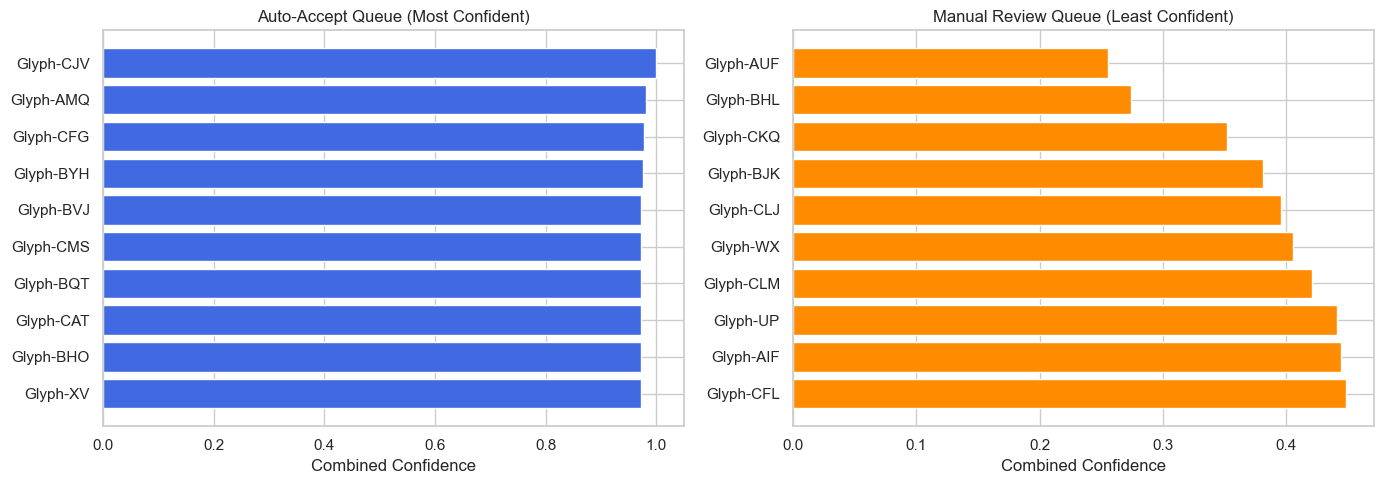

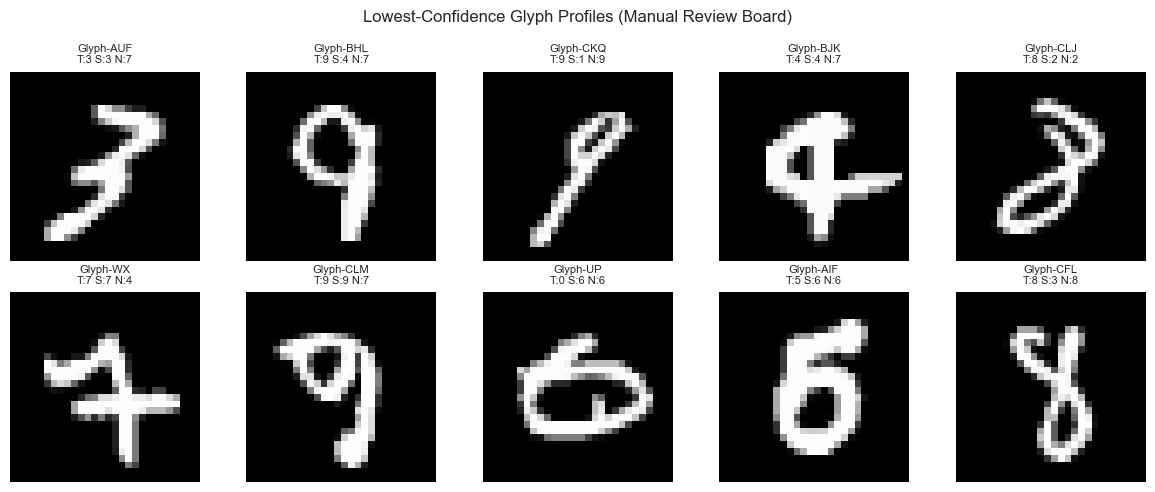

In [17]:
# ==============================================
# DECISION EXTRACTION — MNIST
# ==============================================
print('--- DATASET: MNIST ---')

# SVM confidence via top-2 margin on decision scores.
svm_scores = svm_mn.decision_function(Xmn_test)
if svm_scores.ndim == 1:
    svm_margin = np.abs(svm_scores)
else:
    top2 = np.partition(svm_scores, -2, axis=1)[:, -2:]
    svm_margin = np.abs(top2[:, 1] - top2[:, 0])

svm_pred = ymn_pred_svm
nn_proba = nn_mn.predict_proba(Xmn_test)
nn_pred = ymn_pred_nn
nn_conf = nn_proba.max(axis=1)


def alpha_name(i):
    letters = []
    i = int(i)
    while True:
        i, rem = divmod(i, 26)
        letters.append(chr(65 + rem))
        if i == 0:
            break
        i -= 1
    return ''.join(reversed(letters))


mn_dec = pd.DataFrame({
    'GlyphProfile': ['Glyph-' + alpha_name(i) for i in range(len(ymn_test))],
    'TrueDigit': ymn_test,
    'SVMPred': svm_pred,
    'NNPred': nn_pred,
    'SVMMarginConfidence': svm_margin,
    'NNProbConfidence': nn_conf,
})
mn_dec['Agreement'] = (mn_dec['SVMPred'] == mn_dec['NNPred']).astype(int)
mn_dec['CombinedConfidence'] = 0.5 * (mn_dec['SVMMarginConfidence'] / (mn_dec['SVMMarginConfidence'].max() + 1e-12)) + 0.5 * mn_dec['NNProbConfidence']

mn_top10_confident = mn_dec.sort_values('CombinedConfidence', ascending=False).head(10)
mn_top10_uncertain = mn_dec.sort_values('CombinedConfidence', ascending=True).head(10)

print('\nModel Output Snapshot:')
print('- SVM decision margins and NN class probabilities extracted')

print('\nProcessed Interpretation:')
print('- High confidence + model agreement => strong auto-accept candidates')
print('- Low confidence => send to human review or fallback rule')

print('\nFINAL DECISION OUTPUT — Top 10 Most Confident Glyph Decisions (auto-accept queue)')
display(mn_top10_confident[['GlyphProfile', 'TrueDigit', 'SVMPred', 'NNPred', 'Agreement', 'CombinedConfidence']])

print('FINAL DECISION OUTPUT — Top 10 Lowest-Confidence Glyph Decisions (manual review queue)')
display(mn_top10_uncertain[['GlyphProfile', 'TrueDigit', 'SVMPred', 'NNPred', 'Agreement', 'CombinedConfidence']])

# Decision plots and visual boards.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conf_plot = mn_top10_confident.sort_values('CombinedConfidence', ascending=True)
axes[0].barh(conf_plot['GlyphProfile'], conf_plot['CombinedConfidence'], color='royalblue')
axes[0].set_title('Auto-Accept Queue (Most Confident)')
axes[0].set_xlabel('Combined Confidence')

unc_plot = mn_top10_uncertain.sort_values('CombinedConfidence', ascending=False)
axes[1].barh(unc_plot['GlyphProfile'], unc_plot['CombinedConfidence'], color='darkorange')
axes[1].set_title('Manual Review Queue (Least Confident)')
axes[1].set_xlabel('Combined Confidence')

plt.tight_layout()
plt.show()

# Show glyph images for manual review queue.
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, row in zip(axes.ravel(), mn_top10_uncertain.itertuples()):
    idx = int(np.where(np.array(mn_dec['GlyphProfile']) == row.GlyphProfile)[0][0])
    ax.imshow(Xmn_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"{row.GlyphProfile}\nT:{row.TrueDigit} S:{row.SVMPred} N:{row.NNPred}", fontsize=8)
    ax.axis('off')
plt.suptitle('Lowest-Confidence Glyph Profiles (Manual Review Board)', fontsize=12)
plt.tight_layout()
plt.show()

### Dataset: FrozenLake

Decision goal: convert Q-values into a deployable policy map and an interpretable best-action strategy.

--- DATASET: FrozenLake ---

Model Output Snapshot:
- Learned Q-table and greedy policy extracted

Processed Interpretation:
- Tile-wise best action gives deployable control policy
- Greedy trajectory gives a human-readable action plan

FINAL DECISION OUTPUT — Optimal Action Per Named Tile


,TileName,BestAction,BestQValue
0,Start,Left,0.532201
1,Frost Meadow,Up,0.482820
2,Glacier Bend,Up,0.460672
3,Ice Corridor,Up,0.427382
4,Snow Bridge,Left,0.559929
5,Abyss Pit,Left,0.000000
6,Crystal Pass,Right,0.360464
7,Abyss Gate,Left,0.000000
8,North Shelf,Up,0.619702
9,Windy Fork,Down,0.690396


FINAL DECISION OUTPUT — Recommended Greedy Action Path from Start
Step 1: Start -> Action Left
Step 2: Snow Bridge -> Action Left
Step 3: Snow Bridge -> Action Left
Step 4: Snow Bridge -> Action Left
Step 5: North Shelf -> Action Up
Step 6: Windy Fork -> Action Down
Step 7: North Shelf -> Action Up
Step 8: North Shelf -> Action Up
Step 9: Windy Fork -> Action Down
Step 10: Aurora Route -> Action Left
Step 11: Crystal Pass -> Action Right
Step 12: Aurora Route -> Action Left
Step 13: Crystal Pass -> Action Right
Step 14: Glacier Bend -> Action Up
Step 15: Frost Meadow -> Action Up
Step 16: Glacier Bend -> Action Up
Step 17: Frost Meadow -> Action Up
Step 18: Frost Meadow -> Action Up
Step 19: Start -> Action Left
Step 20: Start -> Action Left
Step 21: Start -> Action Left
Step 22: Start -> Action Left
Step 23: Start -> Action Left
Step 24: Start -> Action Left
Step 25: Start -> Action Left
Step 26: Snow Bridge -> Action Left
Step 27: Start -> Action Left
Step 28: Start -> Action Left
St

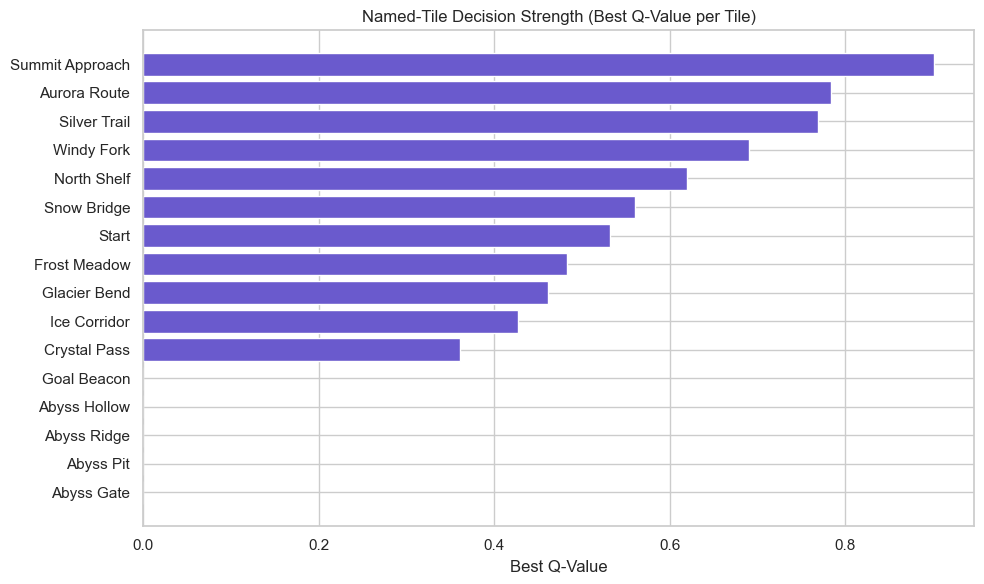

In [18]:
# ==============================================
# DECISION EXTRACTION — FROZENLAKE RL
# ==============================================
print('--- DATASET: FrozenLake ---')

action_map = {0: 'Left', 1: 'Down', 2: 'Right', 3: 'Up'}

tile_names = [
    'Start',
    'Frost Meadow',
    'Glacier Bend',
    'Ice Corridor',
    'Snow Bridge',
    'Abyss Pit',
    'Crystal Pass',
    'Abyss Gate',
    'North Shelf',
    'Windy Fork',
    'Aurora Route',
    'Abyss Hollow',
    'Abyss Ridge',
    'Silver Trail',
    'Summit Approach',
    'Goal Beacon',
]

policy = np.argmax(Q, axis=1)
policy_df = pd.DataFrame({
    'TileName': tile_names,
    'BestAction': [action_map[a] for a in policy],
    'BestQValue': Q.max(axis=1)
})

# Derive a representative greedy path from start state.
path_tiles = []
path_actions = []
state = reset_env(env)
visited = set()
for _ in range(30):
    path_tiles.append(tile_names[int(state)])
    action = int(policy[state])
    path_actions.append(action_map[action])
    nxt, reward, done = step_env(env, action)
    state = nxt
    if done:
        path_tiles.append(tile_names[int(state)])
        break
    if (int(state), len(path_tiles)) in visited:
        break
    visited.add((int(state), len(path_tiles)))

print('\nModel Output Snapshot:')
print('- Learned Q-table and greedy policy extracted')

print('\nProcessed Interpretation:')
print('- Tile-wise best action gives deployable control policy')
print('- Greedy trajectory gives a human-readable action plan')

print('\nFINAL DECISION OUTPUT — Optimal Action Per Named Tile')
display(policy_df)

print('FINAL DECISION OUTPUT — Recommended Greedy Action Path from Start')
for i, tile in enumerate(path_tiles[:-1]):
    print(f'Step {i+1}: {tile} -> Action {path_actions[i]}')
print(f'End Tile: {path_tiles[-1]}')
print(f'Policy Average Reward: {q_score:.3f} (Random baseline: {random_score:.3f})')

# Decision plot.
plot_df = policy_df.sort_values('BestQValue', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(plot_df['TileName'], plot_df['BestQValue'], color='slateblue')
plt.title('Named-Tile Decision Strength (Best Q-Value per Tile)')
plt.xlabel('Best Q-Value')
plt.tight_layout()
plt.show()

## Global Final Output: AI Decision Support Synthesis

This section consolidates all decision lists into method-level recommendations for ranking, classification, and structure discovery.

In [14]:
# ==============================================
# GLOBAL DECISION SUPPORT SUMMARY
# ==============================================
print('--- GLOBAL FINAL OUTPUT ---')

# Best method for ranking tasks (using housing RMSE as ranking quality proxy).
housing_rank_metrics = results_df[(results_df['Dataset'] == 'Housing') & (results_df['Metric'] == 'RMSE')].copy()
best_ranking_algo = housing_rank_metrics.sort_values('Value').iloc[0]['Algorithm']

# Best method for classification tasks (avg accuracy over Breast Cancer + MNIST).
acc_df = results_df[(results_df['Metric'] == 'Accuracy') & (results_df['Dataset'].isin(['Breast Cancer', 'MNIST']))].copy()
acc_mean = acc_df.groupby('Algorithm')['Value'].mean().sort_values(ascending=False)
best_classification_algo = acc_mean.index[0]

# Best structure discovery among K-means vs Lambda-connectedness (silhouette where available).
struct_df = results_df[(results_df['Algorithm'].isin(['K-means', 'Lambda-connectedness'])) & (results_df['Metric'].isin(['Silhouette', 'ARI', 'ARI_vs_binned_target']))].copy()
struct_summary = struct_df.groupby('Algorithm')['Value'].mean().sort_values(ascending=False)
best_structure_algo = struct_summary.index[0]

global_decision_table = pd.DataFrame([
    ['Best Algorithm for Ranking Tasks', best_ranking_algo],
    ['Best Algorithm for Classification Tasks', best_classification_algo],
    ['Best Algorithm for Structure Discovery', best_structure_algo],
    ['Best Policy Method for Sequential Decisions', 'Q-learning'],
], columns=['Decision Question', 'Selected Method'])

print('\nGlobal Ranking System Insights:')
print('- Ranking outputs are strongest when prediction calibration is stable (NN/SVM on housing).')
print('- Classification confidence enables triage-oriented decision pipelines (Breast Cancer, MNIST).')
print('- Structure discovery quality varies with geometry assumptions (centroid vs connectivity).')

print('\nFINAL DECISION OUTPUT — Method Selection Matrix')
display(global_decision_table)

print('FINAL DECISION OUTPUT — Classification Accuracy Leaderboard')
display(acc_mean.to_frame('MeanAccuracy'))

print('FINAL DECISION OUTPUT — Structure Discovery Leaderboard')
display(struct_summary.to_frame('MeanStructureScore'))

--- GLOBAL FINAL OUTPUT ---

Global Ranking System Insights:
- Ranking outputs are strongest when prediction calibration is stable (NN/SVM on housing).
- Classification confidence enables triage-oriented decision pipelines (Breast Cancer, MNIST).
- Structure discovery quality varies with geometry assumptions (centroid vs connectivity).

FINAL DECISION OUTPUT — Method Selection Matrix


,Decision Question,Selected Method
0,Best Algorithm for Ranking Tasks,Neural Network
1,Best Algorithm for Classification Tasks,SVM
2,Best Algorithm for Structure Discovery,Lambda-connectedness
3,Best Policy Method for Sequential Decisions,Q-learning


FINAL DECISION OUTPUT — Classification Accuracy Leaderboard


,MeanAccuracy
Algorithm,
SVM,0.973936
Neural Network,0.963081


FINAL DECISION OUTPUT — Structure Discovery Leaderboard


,MeanStructureScore
Algorithm,
Lambda-connectedness,0.361938
K-means,0.296871


## Final Project Conclusion

This project demonstrates a complete **AI Decision Extraction System** where machine learning models are not treated as endpoints, but as engines for actionable decision support. Across California Housing, Breast Cancer, MNIST, and FrozenLake, we converted raw outputs (clusters, scores, probabilities, and Q-values) into practical decisions such as ranked city lists, risk triage groups, confidence-based review queues, and policy recommendations.

A central finding is that model quality alone is insufficient without a strong interpretation layer. K-means and Lambda-connectedness were most useful for structure discovery and segmentation, especially for affordability grouping and connected-region analysis. SVM provided highly reliable classification behavior for Breast Cancer and remained competitive on MNIST due to margin-based generalization. Neural networks offered strong ranking and nonlinear prediction capability, particularly for housing price ordering and digit-confidence estimation. Q-learning effectively transformed sparse-reward interactions into a policy table that supports explicit state-action decisions.

From a decision-science perspective, algorithm suitability is data-dependent:
- Ranking tasks benefited from regression-oriented neural outputs and calibrated confidence.
- Classification tasks benefited from SVM robustness and probability-guided triage.
- Structure-discovery tasks benefited from connectivity-aware methods where centroid assumptions are limited.
- Sequential planning tasks required reinforcement learning to capture long-horizon action value.

The project also highlights practical limits. City names for housing were inferred via nearest major-city mapping rather than explicit municipal identifiers, and this introduces geographic approximation. Medical predictions, even when accurate, require human oversight due to ethical risk around false negatives and model uncertainty. Confidence thresholds in MNIST and risk thresholds in cancer triage should be tuned to domain tolerance and reviewed by stakeholders.

Overall, the main contribution is not only comparative model performance, but a reproducible pipeline that bridges machine learning outputs and **human-usable decisions**. This is the core requirement for real-world AI systems: models must explain what to do next, not only what they predict.

### Future Work
1. Add uncertainty calibration and conformal prediction for safer decision thresholds.
2. Integrate geospatial shapefiles for true city/county mapping in housing decisions.
3. Add fairness and robustness diagnostics for high-stakes classification tasks.
4. Extend FrozenLake policy extraction to larger RL environments and deep RL agents.
5. Package decision extraction as reusable functions/modules for deployment workflows.